# ML Results Analysis

Comprehensive analysis of the leave-one-dataset-out (LOO) ML experiments.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load results
results_path = Path('../database/ml_results.parquet')
df = pd.read_parquet(results_path)

print(f"Results shape: {df.shape}")
print(f"\nColumns: {list(df.columns)[:20]}...")  # First 20 columns

Results shape: (4, 36)

Columns: ['run_id', 'created_at_utc', 'experiment_key', 'experiment_version', 'test_dataset', 'symbol', 'interval', 'model_name', 'profile', 'seed', 'n_train_datasets', 'train_datasets_json', 'n_train_rows', 'n_test_rows', 'cv_splits', 'cv_best_roc_auc', 'cv_best_accuracy', 'test_roc_auc', 'test_accuracy', 'best_params_json']...


## 1. Data Overview

In [5]:
# Basic info
print("Dataset Info:")
print(f"Total rows: {len(df)}")
print(f"\nUnique models: {df['model_name'].nunique()}")
print(f"Unique test datasets: {df['test_dataset'].nunique()}")
print(f"Unique symbols: {df['symbol'].nunique()}")
print(f"\nModels: {sorted(df['model_name'].unique())}")
print(f"\nTest datasets:\n{sorted(df['test_dataset'].unique())}")

Dataset Info:
Total rows: 4

Unique models: 3
Unique test datasets: 1
Unique symbols: 1

Models: ['gradient_boosting', 'logistic', 'random_forest']

Test datasets:
['AAPL_15m']


In [6]:
# Data types and missing values
print("Missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nKey metrics dtypes:")
metrics_cols = ['test_roc_auc', 'test_accuracy', 'total_return_pct', 'sharpe', 'max_drawdown_pct']
print(df[metrics_cols].dtypes)

Missing values:
Series([], dtype: int64)

Key metrics dtypes:
test_roc_auc        float64
test_accuracy       float64
total_return_pct    float64
sharpe              float64
max_drawdown_pct    float64
dtype: object


## 2. Model Performance: ROC-AUC and Accuracy

In [7]:
# Group by model
model_perf = df.groupby('model_name')[['test_roc_auc', 'test_accuracy', 'cv_best_roc_auc']].agg(['mean', 'std', 'min', 'max'])
print("Model Performance Summary:")
print(model_perf.round(4))

Model Performance Summary:
                  test_roc_auc                      test_accuracy       \
                          mean  std     min     max          mean  std   
model_name                                                               
gradient_boosting       0.5236  NaN  0.5236  0.5236        0.5008  NaN   
logistic                0.5279  0.0  0.5279  0.5279        0.5232  0.0   
random_forest           0.5329  NaN  0.5329  0.5329        0.5080  NaN   

                                  cv_best_roc_auc                       
                      min     max            mean  std     min     max  
model_name                                                              
gradient_boosting  0.5008  0.5008          0.5704  NaN  0.5704  0.5704  
logistic           0.5232  0.5232          0.5596  0.0  0.5596  0.5596  
random_forest      0.5080  0.5080          0.5749  NaN  0.5749  0.5749  


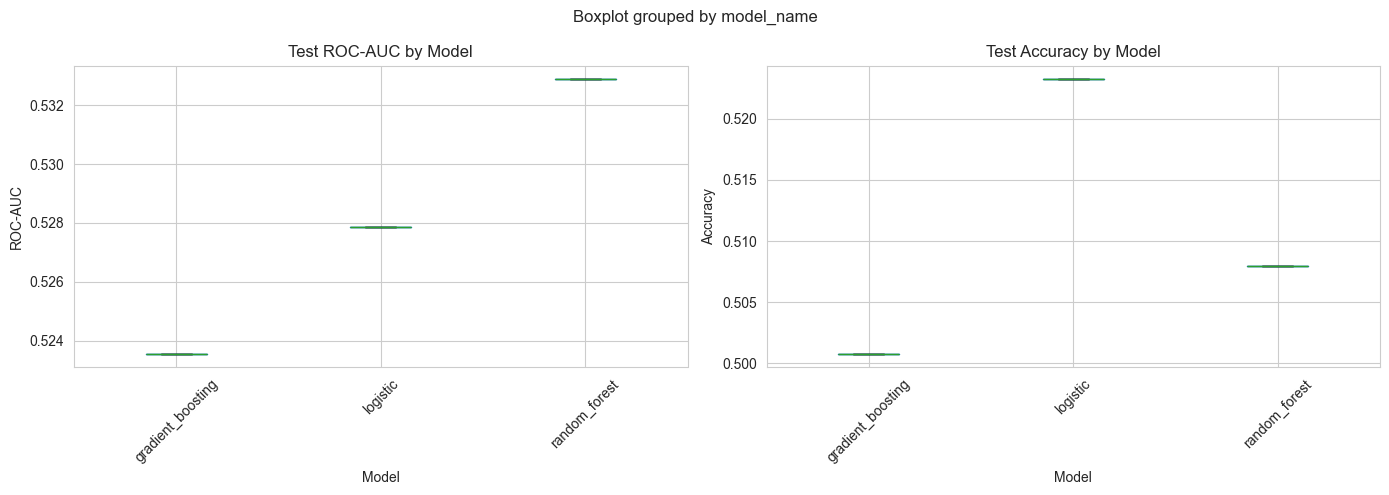


Mean Test ROC-AUC by Model:
model_name
random_forest        0.532873
logistic             0.527859
gradient_boosting    0.523561
Name: test_roc_auc, dtype: float64


In [8]:
# Visualize model performance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC-AUC by model
df.boxplot(column='test_roc_auc', by='model_name', ax=axes[0])
axes[0].set_title('Test ROC-AUC by Model')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('ROC-AUC')
plt.sca(axes[0])
plt.xticks(rotation=45)

# Accuracy by model
df.boxplot(column='test_accuracy', by='model_name', ax=axes[1])
axes[1].set_title('Test Accuracy by Model')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Accuracy')
plt.sca(axes[1])
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("\nMean Test ROC-AUC by Model:")
print(df.groupby('model_name')['test_roc_auc'].mean().sort_values(ascending=False))

## 3. Backtest Metrics Analysis

In [9]:
# Backtest performance summary
backtest_cols = ['total_return_pct', 'buy_hold_return_pct', 'excess_return_pct', 'sharpe', 'max_drawdown_pct']
backtest_summary = df[backtest_cols].describe()
print("Backtest Metrics Summary:")
print(backtest_summary.round(4))

Backtest Metrics Summary:
       total_return_pct  buy_hold_return_pct  excess_return_pct  sharpe  \
count            4.0000               4.0000             4.0000  4.0000   
mean             0.3673               1.0251            -0.6579  0.7462   
std              4.7074               0.0000             4.7074  4.2940   
min             -3.4703               1.0251            -4.4955 -2.7826   
25%             -3.4703               1.0251            -4.4955 -2.7826   
50%             -0.6054               1.0251            -1.6306 -0.0834   
75%              3.2322               1.0251             2.2070  3.4454   
max              6.1503               1.0251             5.1251  5.9342   

       max_drawdown_pct  
count            4.0000  
mean             9.1864  
std              3.2090  
min              6.1865  
25%              6.5246  
50%              9.2991  
75%             11.9609  
max             11.9609  


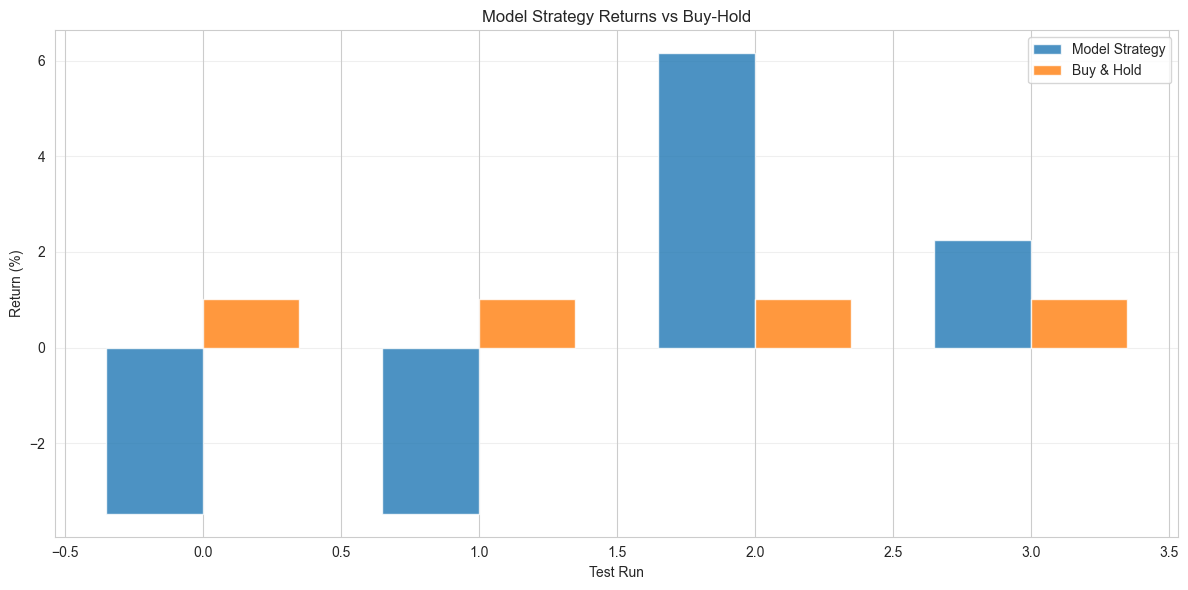

In [10]:
# Returns comparison: Model strategy vs Buy-Hold
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(df))
width = 0.35

ax.bar(x - width/2, df['total_return_pct'], width, label='Model Strategy', alpha=0.8)
ax.bar(x + width/2, df['buy_hold_return_pct'], width, label='Buy & Hold', alpha=0.8)

ax.set_xlabel('Test Run')
ax.set_ylabel('Return (%)')
ax.set_title('Model Strategy Returns vs Buy-Hold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

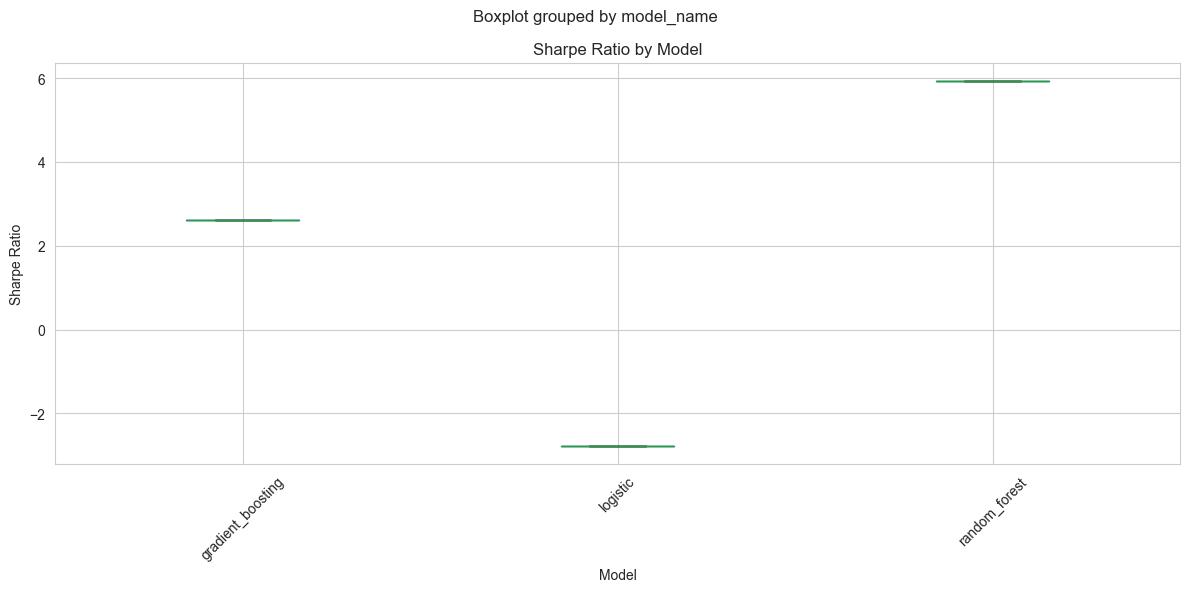


Sharpe Ratio Statistics by Model:
                   count    mean  std     min     25%     50%     75%     max
model_name                                                                   
gradient_boosting    1.0  2.6157  NaN  2.6157  2.6157  2.6157  2.6157  2.6157
logistic             2.0 -2.7826  0.0 -2.7826 -2.7826 -2.7826 -2.7826 -2.7826
random_forest        1.0  5.9342  NaN  5.9342  5.9342  5.9342  5.9342  5.9342


In [11]:
# Sharpe ratio distribution
fig, ax = plt.subplots(figsize=(12, 6))

df.boxplot(column='sharpe', by='model_name', ax=ax)
ax.set_title('Sharpe Ratio by Model')
ax.set_xlabel('Model')
ax.set_ylabel('Sharpe Ratio')
plt.sca(ax)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nSharpe Ratio Statistics by Model:")
print(df.groupby('model_name')['sharpe'].describe().round(4))

## 4. Performance by Dataset

In [12]:
# Group by test dataset
dataset_perf = df.groupby('test_dataset')[['test_roc_auc', 'test_accuracy', 'total_return_pct', 'sharpe']].mean()
print("Average Performance by Test Dataset:")
print(dataset_perf.round(4).sort_values('test_roc_auc', ascending=False))

Average Performance by Test Dataset:
              test_roc_auc  test_accuracy  total_return_pct  sharpe
test_dataset                                                       
AAPL_15m             0.528         0.5138            0.3673  0.7462


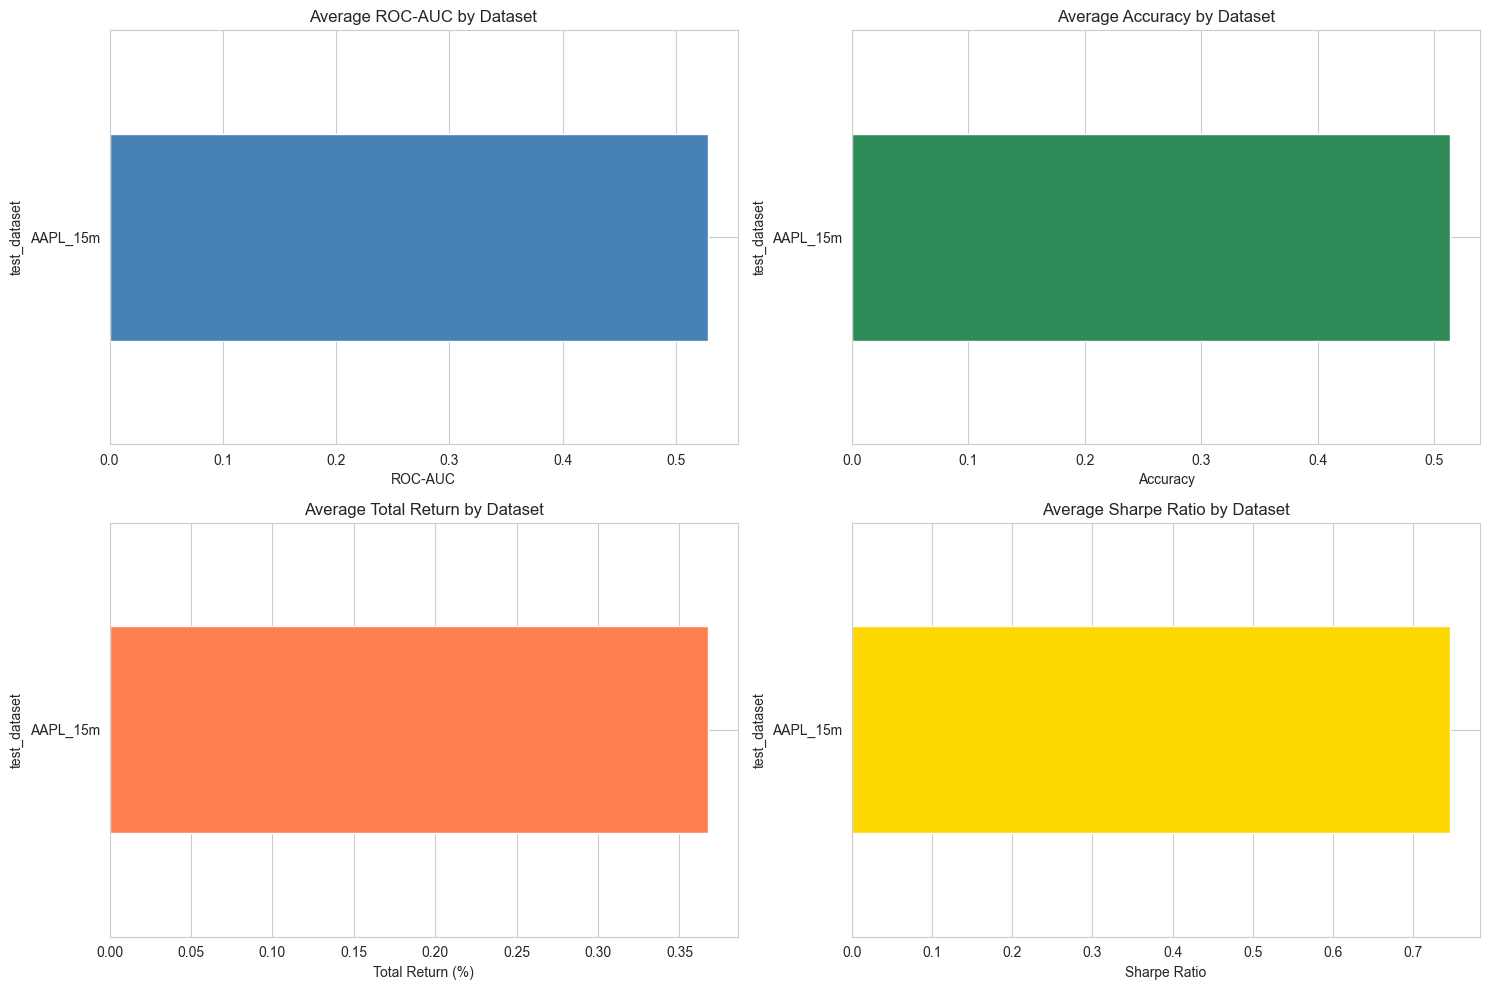

In [13]:
# Visualize performance by dataset
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# ROC-AUC by dataset
dataset_perf_sorted = dataset_perf.sort_values('test_roc_auc', ascending=False)
dataset_perf_sorted['test_roc_auc'].plot(kind='barh', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Average ROC-AUC by Dataset')
axes[0, 0].set_xlabel('ROC-AUC')

# Accuracy by dataset
dataset_perf_sorted = dataset_perf.sort_values('test_accuracy', ascending=False)
dataset_perf_sorted['test_accuracy'].plot(kind='barh', ax=axes[0, 1], color='seagreen')
axes[0, 1].set_title('Average Accuracy by Dataset')
axes[0, 1].set_xlabel('Accuracy')

# Return by dataset
dataset_perf_sorted = dataset_perf.sort_values('total_return_pct', ascending=False)
dataset_perf_sorted['total_return_pct'].plot(kind='barh', ax=axes[1, 0], color='coral')
axes[1, 0].set_title('Average Total Return by Dataset')
axes[1, 0].set_xlabel('Total Return (%)')

# Sharpe by dataset
dataset_perf_sorted = dataset_perf.sort_values('sharpe', ascending=False)
dataset_perf_sorted['sharpe'].plot(kind='barh', ax=axes[1, 1], color='gold')
axes[1, 1].set_title('Average Sharpe Ratio by Dataset')
axes[1, 1].set_xlabel('Sharpe Ratio')

plt.tight_layout()
plt.show()

## 5. Best Performing Models

In [23]:
# Top performers by ROC-AUC
print("Top 10 Best Performers (by ROC-AUC):")
top_roc = df.nlargest(10, 'test_roc_auc')[['test_dataset', 'model_name', 'test_roc_auc', 'test_accuracy', 'sharpe', 'total_return_pct']]
print(top_roc.to_string(index=False))

Top 10 Best Performers (by ROC-AUC):
test_dataset        model_name  test_roc_auc  test_accuracy    sharpe  total_return_pct
    AAPL_15m     random_forest      0.532873         0.5080  5.934223          6.150265
    AAPL_15m          logistic      0.527859         0.5232 -2.782564         -3.470312
    AAPL_15m          logistic      0.527859         0.5232 -2.782564         -3.470312
    AAPL_15m gradient_boosting      0.523561         0.5008  2.615750          2.259445


In [24]:
# Top performers by Sharpe ratio
print("\nTop 10 Best Performers (by Sharpe Ratio):")
top_sharpe = df.nlargest(10, 'sharpe')[['test_dataset', 'model_name', 'sharpe', 'total_return_pct', 'max_drawdown_pct', 'test_roc_auc']]
print(top_sharpe.to_string(index=False))


Top 10 Best Performers (by Sharpe Ratio):
test_dataset        model_name    sharpe  total_return_pct  max_drawdown_pct  test_roc_auc
    AAPL_15m     random_forest  5.934223          6.150265          6.186533      0.532873
    AAPL_15m gradient_boosting  2.615750          2.259445          6.637224      0.523561
    AAPL_15m          logistic -2.782564         -3.470312         11.960943      0.527859
    AAPL_15m          logistic -2.782564         -3.470312         11.960943      0.527859


In [25]:
# Top performers by Total Return
print("\nTop 10 Best Performers (by Total Return):")
top_return = df.nlargest(10, 'total_return_pct')[['test_dataset', 'model_name', 'total_return_pct', 'sharpe', 'test_roc_auc', 'max_drawdown_pct']]
print(top_return.to_string(index=False))


Top 10 Best Performers (by Total Return):
test_dataset        model_name  total_return_pct    sharpe  test_roc_auc  max_drawdown_pct
    AAPL_15m     random_forest          6.150265  5.934223      0.532873          6.186533
    AAPL_15m gradient_boosting          2.259445  2.615750      0.523561          6.637224
    AAPL_15m          logistic         -3.470312 -2.782564      0.527859         11.960943
    AAPL_15m          logistic         -3.470312 -2.782564      0.527859         11.960943


## 6. Model vs Dataset Heatmap

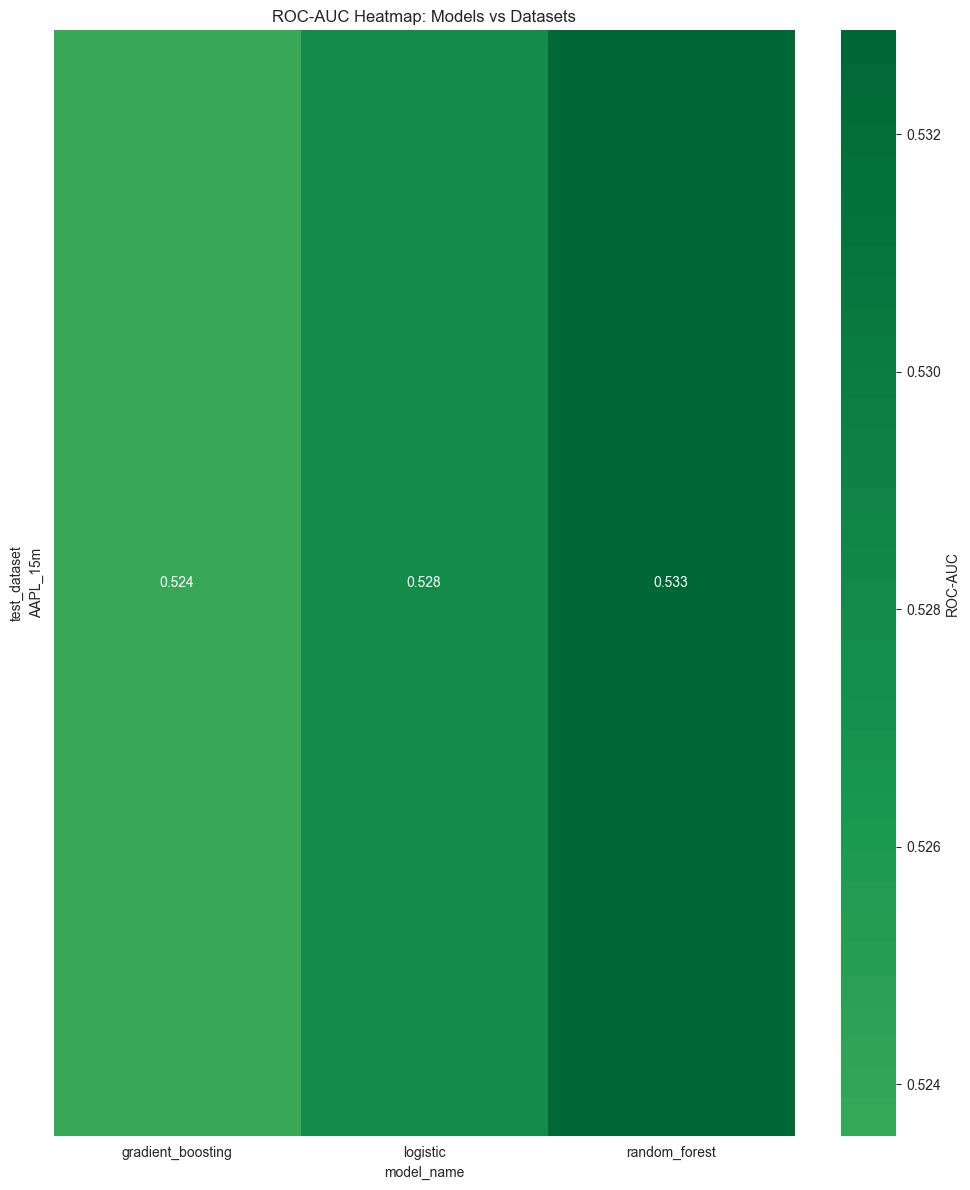

In [17]:
# Create pivot table for heatmap
pivot_roc = df.pivot_table(values='test_roc_auc', index='test_dataset', columns='model_name', aggfunc='mean')

fig, ax = plt.subplots(figsize=(10, 12))
sns.heatmap(pivot_roc, annot=True, fmt='.3f', cmap='RdYlGn', center=0.5, ax=ax, cbar_kws={'label': 'ROC-AUC'})
ax.set_title('ROC-AUC Heatmap: Models vs Datasets')
plt.tight_layout()
plt.show()

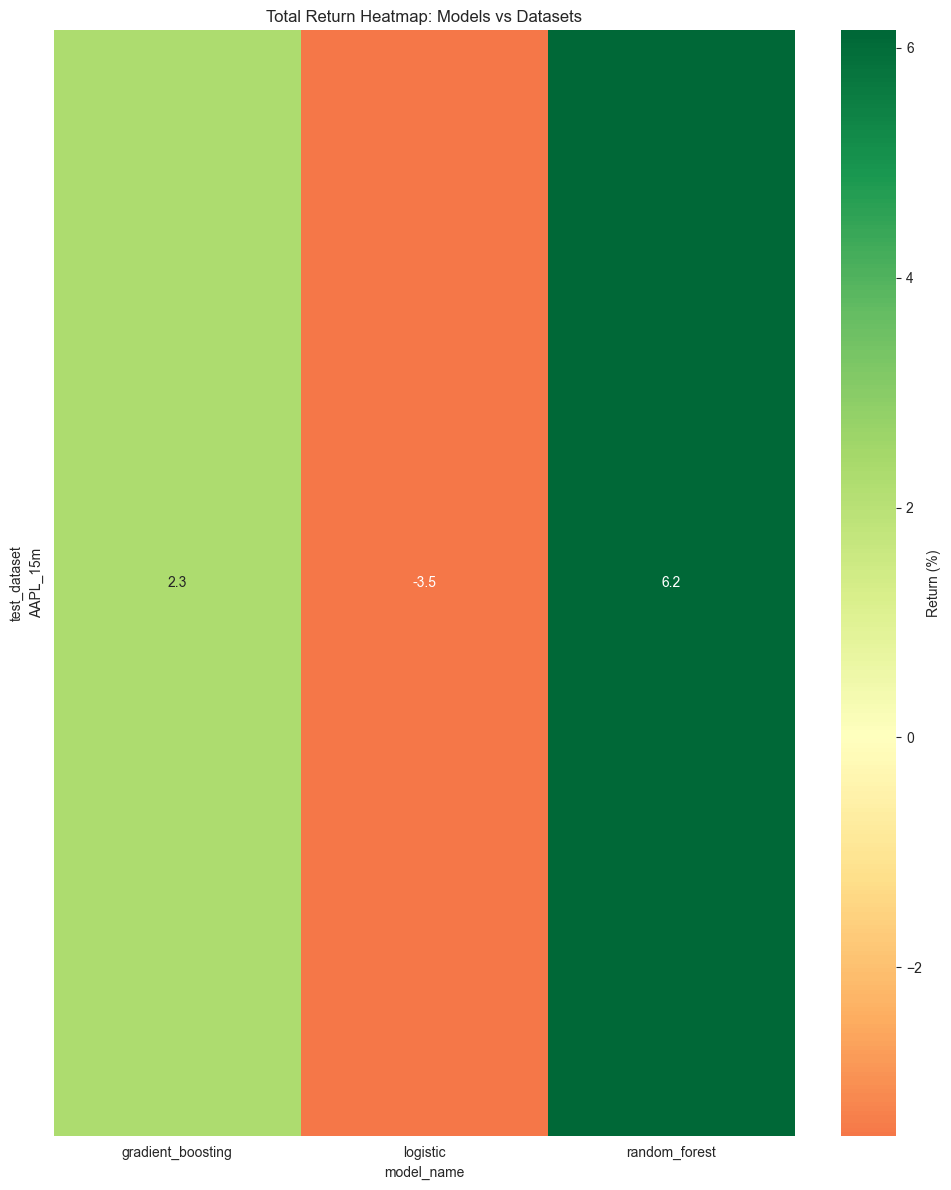

In [18]:
# Return heatmap
pivot_return = df.pivot_table(values='total_return_pct', index='test_dataset', columns='model_name', aggfunc='mean')

fig, ax = plt.subplots(figsize=(10, 12))
sns.heatmap(pivot_return, annot=True, fmt='.1f', cmap='RdYlGn', center=0, ax=ax, cbar_kws={'label': 'Return (%)'})
ax.set_title('Total Return Heatmap: Models vs Datasets')
plt.tight_layout()
plt.show()

## 7. Correlation Analysis

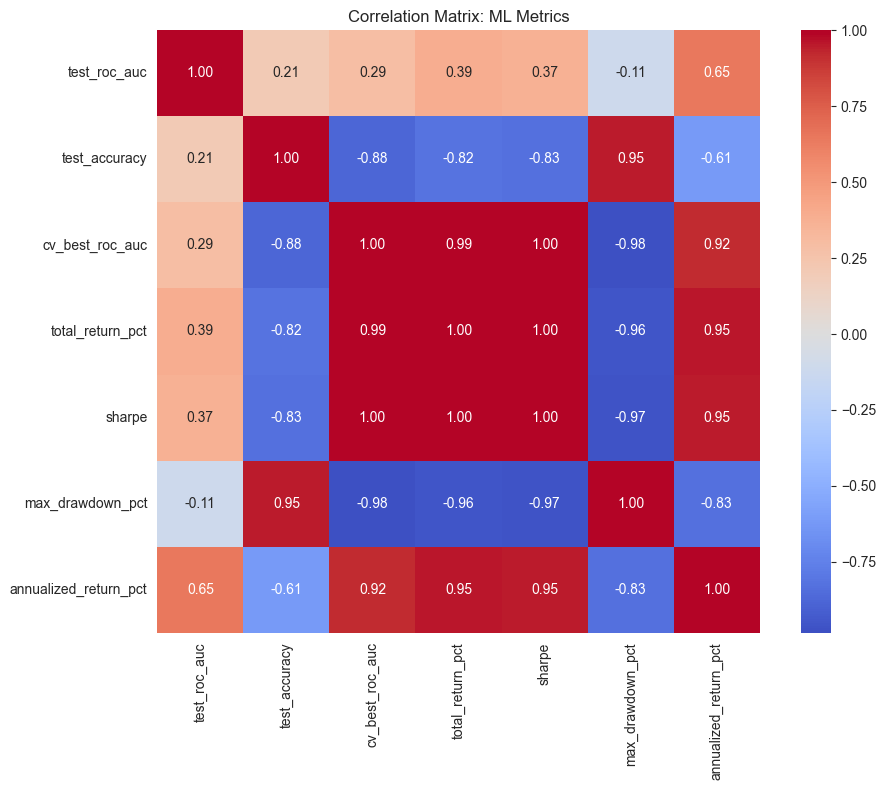


Correlation with Total Return:
total_return_pct         1.000000
sharpe                   0.999731
cv_best_roc_auc          0.994610
annualized_return_pct    0.954129
test_roc_auc             0.388022
test_accuracy           -0.820419
max_drawdown_pct        -0.959148
Name: total_return_pct, dtype: float64


In [19]:
# Correlation between metrics
metrics = ['test_roc_auc', 'test_accuracy', 'cv_best_roc_auc', 'total_return_pct', 'sharpe', 'max_drawdown_pct', 'annualized_return_pct']
corr_matrix = df[metrics].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, square=True)
ax.set_title('Correlation Matrix: ML Metrics')
plt.tight_layout()
plt.show()

print("\nCorrelation with Total Return:")
print(corr_matrix['total_return_pct'].sort_values(ascending=False))

## 8. Summary Statistics

In [20]:
# Overall summary
print("OVERALL EXPERIMENT SUMMARY")
print("="*60)
print(f"Total experiments: {len(df)}")
print(f"Datasets tested: {df['test_dataset'].nunique()}")
print(f"Models evaluated: {df['model_name'].nunique()}")
print(f"Average runs per dataset: {len(df) / df['test_dataset'].nunique():.1f}")

print("\nPREDICTIVE PERFORMANCE:")
print(f"  Mean ROC-AUC: {df['test_roc_auc'].mean():.4f} (+/- {df['test_roc_auc'].std():.4f})")
print(f"  Mean Accuracy: {df['test_accuracy'].mean():.4f} (+/- {df['test_accuracy'].std():.4f})")
print(f"  Mean CV ROC-AUC: {df['cv_best_roc_auc'].mean():.4f}")

print("\nBACKTEST PERFORMANCE:")
print(f"  Mean Total Return: {df['total_return_pct'].mean():.2f}%")
print(f"  Mean Buy-Hold Return: {df['buy_hold_return_pct'].mean():.2f}%")
print(f"  Mean Excess Return: {df['excess_return_pct'].mean():.2f}%")
print(f"  Mean Sharpe Ratio: {df['sharpe'].mean():.4f}")
print(f"  Mean Max Drawdown: {df['max_drawdown_pct'].mean():.2f}%")
print(f"  Mean Annualized Return: {df['annualized_return_pct'].mean():.2f}%")

print("\nTRADE STATISTICS:")
print(f"  Mean # of Trades: {df['num_trades'].mean():.1f}")
print(f"  Mean Signal Coverage: {df['signal_coverage'].mean():.2%}")
print(f"  Mean Train Rows: {df['n_train_rows'].mean():.0f}")
print(f"  Mean Test Rows: {df['n_test_rows'].mean():.0f}")

OVERALL EXPERIMENT SUMMARY
Total experiments: 4
Datasets tested: 1
Models evaluated: 3
Average runs per dataset: 4.0

PREDICTIVE PERFORMANCE:
  Mean ROC-AUC: 0.5280 (+/- 0.0038)
  Mean Accuracy: 0.5138 (+/- 0.0112)
  Mean CV ROC-AUC: 0.5661

BACKTEST PERFORMANCE:
  Mean Total Return: 0.37%
  Mean Buy-Hold Return: 1.03%
  Mean Excess Return: -0.66%
  Mean Sharpe Ratio: 0.7462
  Mean Max Drawdown: 9.19%
  Mean Annualized Return: 98.56%

TRADE STATISTICS:
  Mean # of Trades: 244.2
  Mean Signal Coverage: 30.04%
  Mean Train Rows: 32500
  Mean Test Rows: 1250


In [ ]:
# Models ranked by different criteria
print("\nMODEL RANKINGS:")
print("\nBy ROC-AUC (test):")
print(df.groupby('model_name')['test_roc_auc'].mean().sort_values(ascending=False).round(4))
print("\nBy Sharpe Ratio:")
print(df.groupby('model_name')['sharpe'].mean().sort_values(ascending=False).round(4))

print("\nBy Total Return:")
print(df.groupby('model_name')['total_return_pct'].mean().sort_values(ascending=False).round(2))

print("\nBy Excess Return (vs Buy-Hold):")
print(df.groupby('model_name')['excess_return_pct'].mean().sort_values(ascending=False).round(2))


MODEL RANKINGS:

By ROC-AUC (test):
model_name
random_forest        0.5329
logistic             0.5279
gradient_boosting    0.5236
Name: test_roc_auc, dtype: float64

By Sharpe Ratio:
model_name
random_forest        5.9342
gradient_boosting    2.6157
logistic            -2.7826
Name: sharpe, dtype: float64

By Total Return:
model_name
random_forest        6.15
gradient_boosting    2.26
logistic            -3.47
Name: total_return_pct, dtype: float64

By Excess Return (vs Buy-Hold):
model_name
random_forest        5.13
gradient_boosting    1.23
logistic            -4.50
Name: excess_return_pct, dtype: float64


In [22]:
df.to_csv("ml_results.csv")